In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded")

Libraries loaded


In [6]:
nobel_data = pd.read_csv("nobel_winners.csv")

print(f"Got {len(nobel_data)} winners in total")
nobel_data.head()

Got 969 winners in total


,prize_year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,gender,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


In [7]:
print(nobel_data.columns.tolist())
print("\n")
print(nobel_data.info())

['prize_year', 'category', 'prize', 'motivation', 'prize_share', 'laureate_id', 'laureate_type', 'full_name', 'birth_date', 'birth_city', 'birth_country', 'gender', 'organization_name', 'organization_city', 'organization_country', 'death_date', 'death_city', 'death_country']


<class 'pandas.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   prize_year            969 non-null    int64
 1   category              969 non-null    str  
 2   prize                 969 non-null    str  
 3   motivation            881 non-null    str  
 4   prize_share           969 non-null    str  
 5   laureate_id           969 non-null    int64
 6   laureate_type         969 non-null    str  
 7   full_name             969 non-null    str  
 8   birth_date            938 non-null    str  
 9   birth_city            941 non-null    str  
 10  birth_country         943 non-null 

In [8]:
clean_df = nobel_data.copy()

clean_df['birth_country'] = clean_df['birth_country'].fillna('Unknown')
clean_df['gender'] = clean_df['gender'].fillna('Unknown')

clean_df['decade_won'] = (clean_df['prize_year'] // 10) * 10

from datetime import datetime
clean_df['birth_year'] = pd.to_datetime(clean_df['birth_date'], errors='coerce').dt.year
clean_df['age_won'] = clean_df['prize_year'] - clean_df['birth_year']

print("Data is cleaned up")

Data is cleaned up


# Nobel Laureates Analysis

## Project Overview
This analysis answers 8 questions about patterns and trends in Nobel Prize history from 1901 to present Nobel.

## Questions to Answer:
1. Which category won the most Nobel Prizes?
2. How is the gender ratio like for Nobel Prize winner?
3. How has the number of prizes changed over time?
4. Who are the multiple Nobel Prize winners?
5. What is the average age of laureates by category?
6. Which country has the most laureates?
7. What is the gender distribution in each category?
8. Are there any organizations that have won Nobel Prizes?

== MOST NOBEL PRIZES BY CATEGORY ==

Medicine: 227
Physics: 222
Chemistry: 194
Peace: 130
Literature: 113
Economics: 83


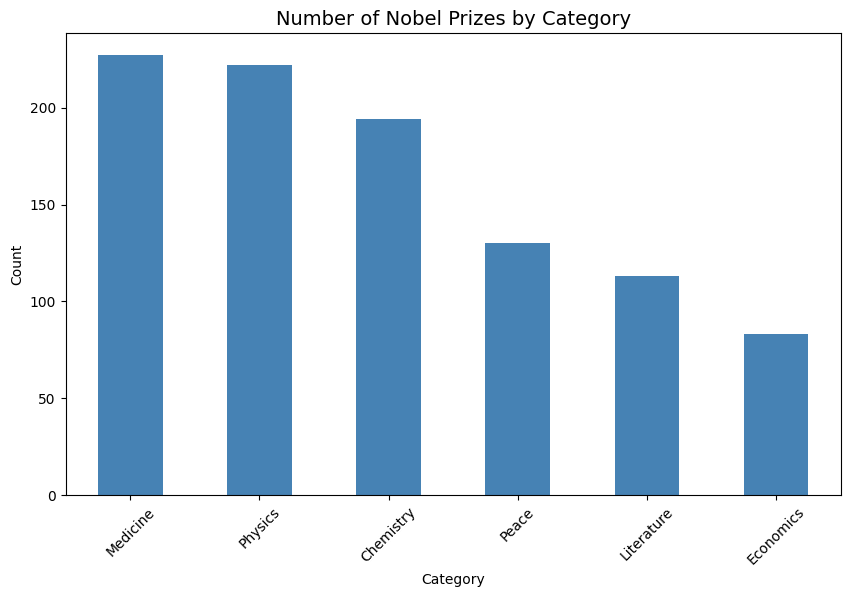


Medicine has the most with 227 prizes


In [9]:
cat_counts = clean_df['category'].value_counts()

print("== MOST NOBEL PRIZES BY CATEGORY ==\n")
for cat, num in cat_counts.items():
    print(f"{cat}: {num}")

plt.figure(figsize=(10,6))
cat_counts.plot(kind='bar', color='steelblue')
plt.title('Number of Nobel Prizes by Category', fontsize=14)
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

print(f"\n{cat_counts.index[0]} has the most with {cat_counts.iloc[0]} prizes")

== GENDER BREAKDOWN ==

Male: 893 (92.2%)
Female: 50 (5.2%)
Unknown: 26 (2.7%)


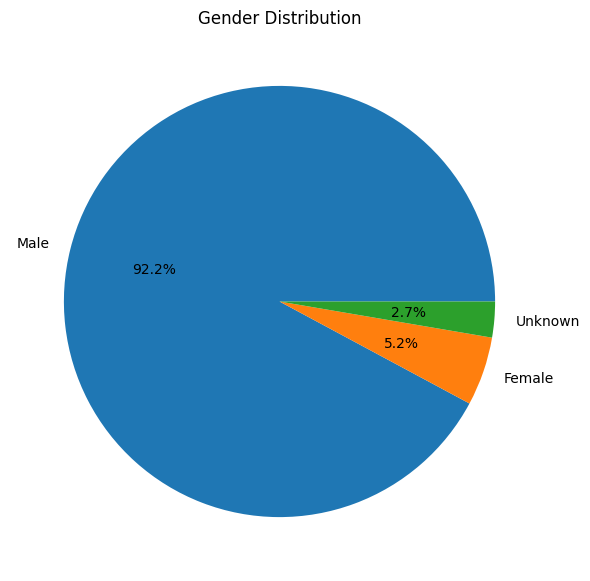


 50 women winners. 5.2% of the total number of winners


In [10]:
gender_numbers = clean_df['gender'].value_counts()

print("== GENDER BREAKDOWN ==\n")
for g, num in gender_numbers.items():
    percent = (num / len(clean_df)) * 100
    print(f"{g}: {num} ({percent:.1f}%)")

plt.figure(figsize=(7,7))
plt.pie(gender_numbers, labels=gender_numbers.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

women_count = gender_numbers.get('Female', 0)
print(f"\n {women_count} women winners. {(women_count/len(clean_df))*100:.1f}% of the total number of winners")

First prize was in 1901
Last prize was in 2016


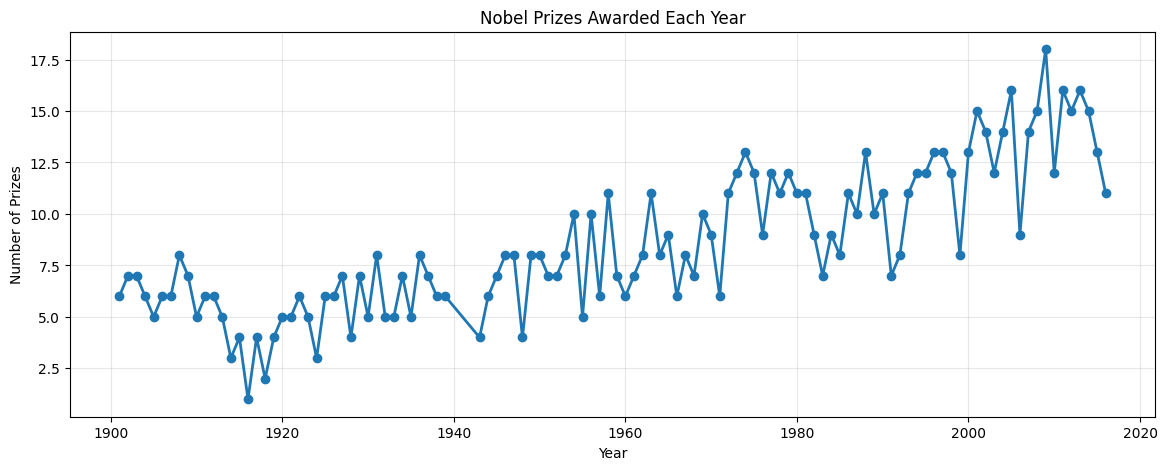

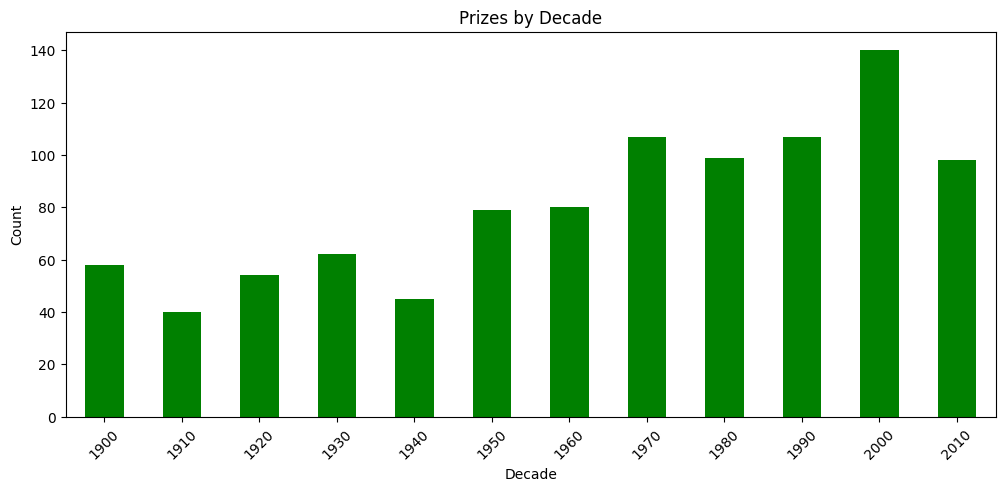

In [11]:
yearly_total = clean_df['prize_year'].value_counts().sort_index()

print(f"First prize was in {yearly_total.index.min()}")
print(f"Last prize was in {yearly_total.index.max()}")

plt.figure(figsize=(14,5))
plt.plot(yearly_total.index, yearly_total.values, 'o-', linewidth=2)
plt.title('Nobel Prizes Awarded Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Prizes')
plt.grid(True, alpha=0.3)
plt.show()


decade_total = clean_df.groupby('decade_won').size()
plt.figure(figsize=(12,5))
decade_total.plot(kind='bar', color='green')
plt.title('Prizes by Decade')
plt.xlabel('Decade')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [13]:
repeated = clean_df[clean_df.duplicated(subset=['full_name'], keep=False)]
winners_multiple = repeated.sort_values('full_name')[['full_name', 'category', 'prize_year']]

print("== PEOPLE WHO WON MULTIPLE TIMES ==\n")

if len(winners_multiple) > 0:
    for name in winners_multiple['full_name'].unique():
        person_info = winners_multiple[winners_multiple['full_name'] == name]
        print(f"\n {name}:")
        for idx, row in person_info.iterrows():
            print(f"   - {row['prize_year']}: {row['category']}")
else:
    print("No multiple winners")


== PEOPLE WHO WON MULTIPLE TIMES ==


 Abdus Salam:
   - 1979: Physics
   - 1979: Physics

 Adam G. Riess:
   - 2011: Physics
   - 2011: Physics

 Adolf Friedrich Johann Butenandt:
   - 1939: Chemistry
   - 1939: Chemistry

 Albert Fert:
   - 2007: Physics
   - 2007: Physics

 Alvin E. Roth:
   - 2012: Economics
   - 2012: Economics

 Antonio Caetano de Abreu Freire Egas Moniz:
   - 1949: Medicine
   - 1949: Medicine

 Barry J. Marshall:
   - 2005: Medicine
   - 2005: Medicine

 Bruce A. Beutler:
   - 2011: Medicine
   - 2011: Medicine

 Carl Bosch:
   - 1931: Chemistry
   - 1931: Chemistry

 Charles Kuen Kao:
   - 2009: Physics
   - 2009: Physics

 Christian de Duve:
   - 1974: Medicine
   - 1974: Medicine

 Claude Cohen-Tannoudji:
   - 1997: Physics
   - 1997: Physics

 Comité international de la Croix Rouge (International Committee of the Red Cross):
   - 1963: Peace
   - 1944: Peace
   - 1917: Peace

 Dale T. Mortensen:
   - 2010: Economics
   - 2010: Economics

 David J. Wineland:

== AVERAGE AGE WHEN WINNING ==

Physics: 55.9 years old
Medicine: 57.9 years old
Chemistry: 58.1 years old
Peace: 61.4 years old
Literature: 64.7 years old
Economics: 67.2 years old


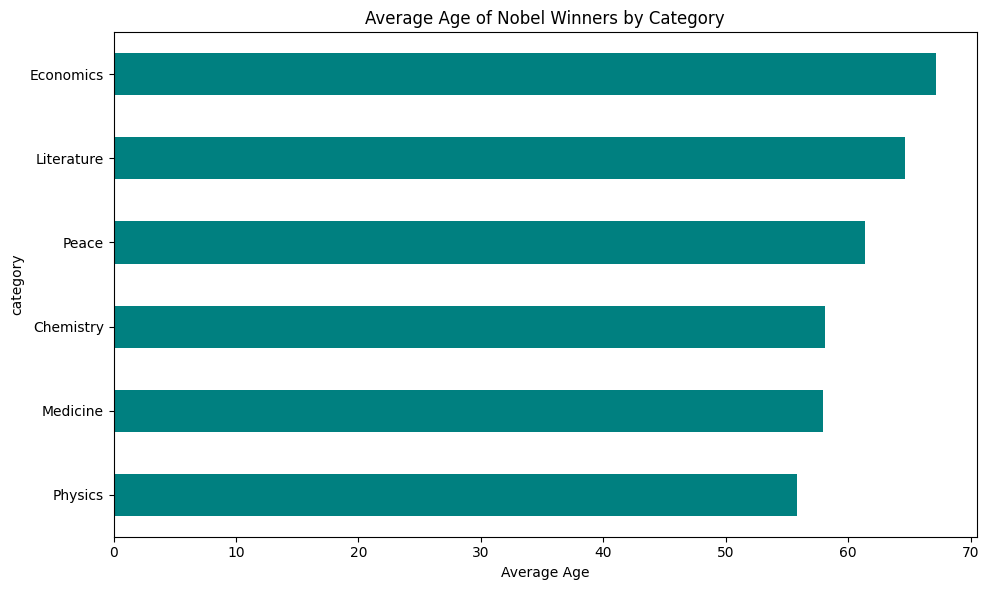

In [14]:
age_clean = clean_df[clean_df['age_won'].between(0, 100)]
avg_age_by_cat = age_clean.groupby('category')['age_won'].mean().sort_values()

print("== AVERAGE AGE WHEN WINNING ==\n")
for cat, age in avg_age_by_cat.items():
    print(f"{cat}: {age:.1f} years old")


plt.figure(figsize=(10,6))
avg_age_by_cat.plot(kind='barh', color='teal')
plt.title('Average Age of Nobel Winners by Category')
plt.xlabel('Average Age')
plt.tight_layout()
plt.show()

== TOP 10 COUNTRIES ==

1. United States of America: 276 winners
2. United Kingdom: 88 winners
3. Germany: 70 winners
4. France: 53 winners
5. Sweden: 30 winners
6. Japan: 29 winners
7. Unknown: 26 winners
8. Russia: 20 winners
9. Netherlands: 19 winners
10. Italy: 18 winners


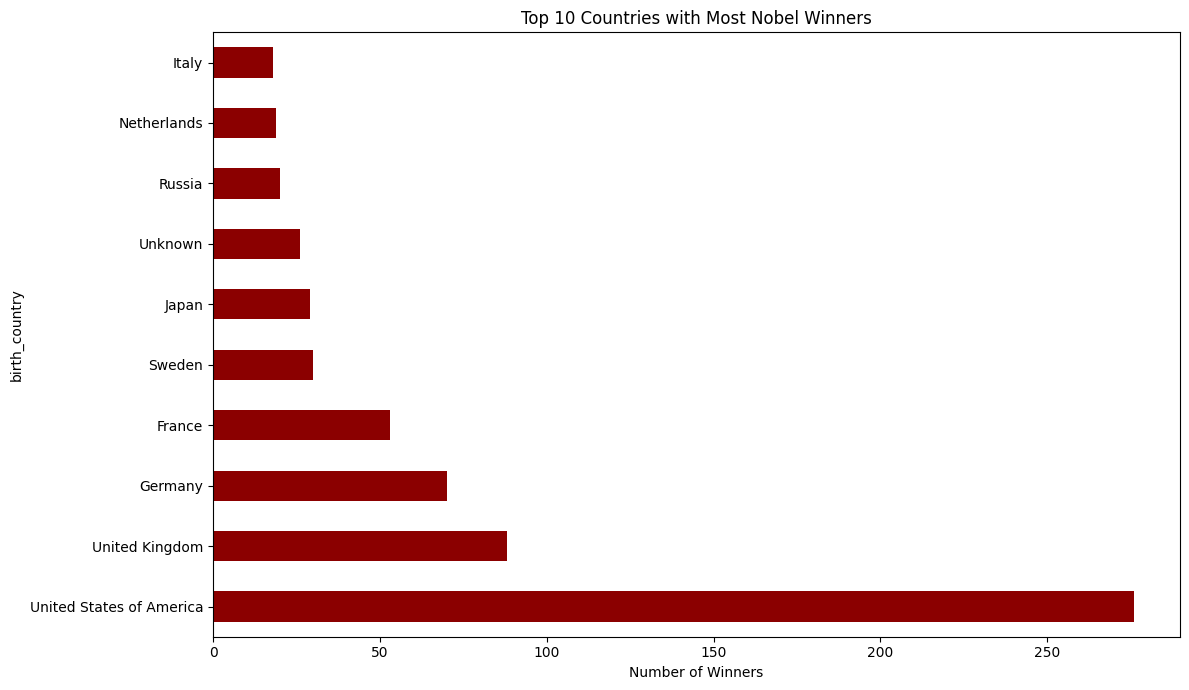

In [16]:
country_top = clean_df['birth_country'].value_counts().head(10)

print("== TOP 10 COUNTRIES ==\n")
for i, (country, num) in enumerate(country_top.items(), 1):
    print(f"{i}. {country}: {num} winners")


plt.figure(figsize=(12,7))
country_top.plot(kind='barh', color='darkred')
plt.title('Top 10 Countries with Most Nobel Winners')
plt.xlabel('Number of Winners')
plt.tight_layout()
plt.show()

== GENDER BY CATEGORY ==

gender      Female  Male  Unknown
category                         
Chemistry        4   190        0
Economics        2    81        0
Literature      14    99        0
Medicine        12   215        0
Peace           16    88       26
Physics          2   220        0


<Figure size 1200x700 with 0 Axes>

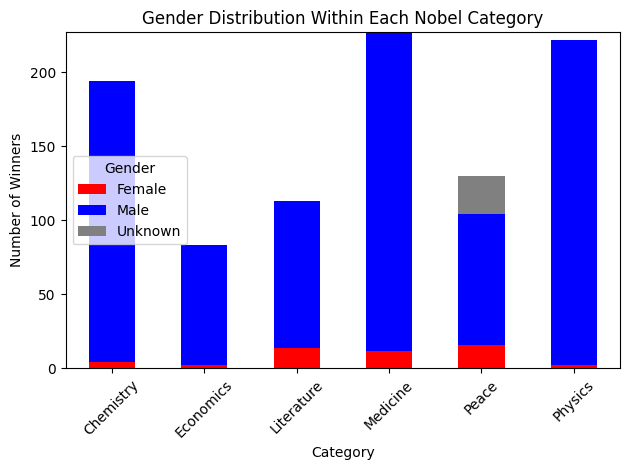

In [19]:
gender_cat_table = pd.crosstab(clean_df['category'], clean_df['gender'])

print("== GENDER BY CATEGORY ==\n")
print(gender_cat_table)


plt.figure(figsize=(12,7))
gender_cat_table.plot(kind='bar', stacked=True, color=['red', 'blue', 'gray'])
plt.title('Gender Distribution Within Each Nobel Category')
plt.xlabel('Category')
plt.ylabel('Number of Winners')
plt.xticks(rotation=45)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

== ORGANIZATIONS THAT WON NOBEL PRIZES ==

🏢 Institut de droit international (Institute of International Law) - Peace (1904)
🏢 Bureau international permanent de la Paix (Permanent International Peace Bureau) - Peace (1910)
🏢 Comité international de la Croix Rouge (International Committee of the Red Cross) - Peace (1917)
🏢 Office international Nansen pour les Réfugiés (Nansen International Office for Refugees) - Peace (1938)
🏢 Comité international de la Croix Rouge (International Committee of the Red Cross) - Peace (1944)
🏢 Friends Service Council (The Quakers) - Peace (1947)
🏢 American Friends Service Committee (The Quakers) - Peace (1947)
🏢 Office of the United Nations High Commissioner for Refugees (UNHCR) - Peace (1954)
🏢 Comité international de la Croix Rouge (International Committee of the Red Cross) - Peace (1963)
🏢 Ligue des Sociétés de la Croix-Rouge (League of Red Cross Societies) - Peace (1963)
🏢 United Nations Children's Fund (UNICEF) - Peace (1965)
🏢 International Labour Or

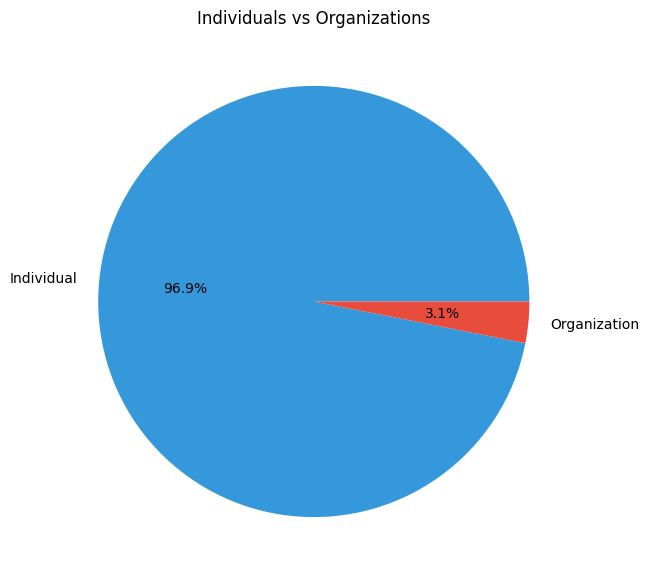

In [21]:
org_winners = clean_df[clean_df['laureate_type'] == 'Organization']

print("== ORGANIZATIONS THAT WON NOBEL PRIZES ==\n")

if len(org_winners) > 0:
    for idx, row in org_winners.iterrows():
        print(f"🏢 {row['full_name']} - {row['category']} ({row['prize_year']})")
else:
    print("No organizations found")

type_counts = clean_df['laureate_type'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#3498DB', '#E74C3C'])
plt.title('Individuals vs Organizations')
plt.show()

## Insights:

- I thought medicines would have the most Nobel Prize winners but suprisingly, physics has the most Nobel Prize winners.
- It's suprising how only 5% of the total number of Nobel Prize winners are women.
- The average age of the winners seems to be older over time. This might indicate that scientific discoveries take longer now.
- It's suprising how US is dominating the number of Nobel Prize winners. I thought other countries such as Germany, with longer history of science would have more winners.
- Literature winners are oldest with the average age of 64, and physics winners are the youngest with the average age of 55.
- Marie Curie is the only person who won in two different science categories.